In [1]:
%load_ext autoreload
%autoreload 2

```{toctree}
:maxdepth: 1
:caption: Contents:

# Walkthrough Example - Spectral Analysis

```{hint}
Before using the `WaveSpectralAnalyzer` class, make sure you have the necessary data and dependencies installed. This example assumes you have time series data from an AQUAlogger and a RBR device.

Users are referred to the THIS LINK for a installation guide of the `oceanicospy` package and its dependencies.
```

This example demonstrates how to use the `WaveSpectralAnalyzer` class from the `oceanicospy.analysis.spectral` module to perform spectral analysis on wave data. We will compute the power spectral density of a two different surface level time series recorded with an AQUAlogger and a RBR device.

# Importing required modules and subpackages

For this example, the modules and packages from `oceanicospy` are imported, as well as some standard libraries for plotting and data manipulation.

In [2]:
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
mpl.rcParams["font.size"] = 12
mpl.rcParams["figure.dpi"] = 150

In [3]:
from oceanicospy.observations.pressure_sensors import AQUAlogger, RBR
from oceanicospy.analysis import spectral

# Pressure data

Deployment data from pressure sensors is loaded as a dictionary, while the sensor data is read from the corresponding sensor files. It has to be clarified that sensors are not deployed either at the same time or location.

In [4]:
measurement_pressure_sensors_paths = ['../data/observations/AQUAlogger/','../data/observations/RBR/']

sampling_AQ = dict(anchoring_depth=1, sensor_height=0.2, sampling_freq=1, burst_length_s=2048,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=1))
sampling_RBR = dict(anchoring_depth=1, sensor_height=0.2, sampling_freq=2, burst_length_s=7200,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=0.5))

For further information about how to upload the sensor data using **oceanicospy**, please refer to the [data loading example](https://oceanicospy.readthedocs.io/en/latest/examples/data_loading.html).

In [5]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict()

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    if 'AQ' in measurement_path:
        object_device = AQUAlogger(measurement_path, sampling_data[idx], filename='AQUAlogger_520PT5.csv')
    else:
        object_device = RBR(measurement_path,sampling_data[idx])

    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

A quick look at the data shows that the pressure signal is sampled at 1Hz for the AQ sensor and 2Hz for the RBR sensor. The raw records contain the original columns from the sensor files, which may have different names and formats.

In [6]:
dict_raw_measurements['AQ'].head()

,units,date,pressure[raw],pressure[bar],depth[raw],depth[m],[]
0,BURSTSTART,5/9/2025 06:00:00 AM,32820,1.001880,0,-0.247502,NaN
1,DATA,5/9/2025 06:00:01 AM,32820,1.001880,0,-0.247502,NaN
2,DATA,5/9/2025 06:00:02 AM,32819,1.001735,0,-0.250864,NaN
3,DATA,5/9/2025 06:00:03 AM,32822,1.002169,0,-0.240797,NaN
4,DATA,5/9/2025 06:00:04 AM,32820,1.001880,0,-0.247502,NaN


In [7]:
dict_raw_measurements['RBR'].head()

,Time,Pressure,Sea pressure,Depth
0,2025-05-09 06:00:00.000,10.080782,-0.051719,-0.051297
1,2025-05-09 06:00:00.500,10.080982,-0.051518,-0.051098
2,2025-05-09 06:00:01.000,10.081144,-0.051356,-0.050937
3,2025-05-09 06:00:01.500,10.080991,-0.051509,-0.051089
4,2025-05-09 06:00:02.000,10.081048,-0.051452,-0.051032


The clean records are then obtained by applying the `get_clean_records` method of the `PressureSensor` class, which performs several processing steps to prepare the data for analysis. This includes standardizing column names, parsing dates, computing depth from pressure, and assigning burst IDs.

In [8]:
dict_clean_measurements['AQ'].head()

,pressure[bar],depth[m],depth_aux[m],burstId,eta[m]
date,,,,,
2025-05-09 10:00:00,1.245722,3.136509,2.307327,1,0.052596
2025-05-09 10:00:01,1.244709,3.124966,2.297273,1,0.041052
2025-05-09 10:00:02,1.237181,3.039040,2.222556,1,-0.044874
2025-05-09 10:00:03,1.243695,3.113418,2.287209,1,0.029503
2025-05-09 10:00:04,1.253249,3.222086,2.382034,1,0.138170


In [9]:
dict_clean_measurements['RBR'].head()

,pressure[bar],depth[m],burstId,eta[m]
date,,,,
2025-05-09 10:00:00.000,1.241829,2.267149,1,0.117985
2025-05-09 10:00:00.500,1.239702,2.246051,1,0.096886
2025-05-09 10:00:01.000,1.235314,2.202530,1,0.053365
2025-05-09 10:00:01.500,1.233978,2.189276,1,0.040110
2025-05-09 10:00:02.000,1.234466,2.194119,1,0.044954


# Using the `WaveSpectralAnalyzer` class

First, we need to instanciate the `WaveSpectralAnalyzer` class, which will allow us to make the spectral analysis for the pressure data. We need to provide the measurement signal and the sampling data as arguments.

`WaveSpectralAnalyzer` will look for measurement signal with a column named `eta[m]`, which is the standard name for the sea surface elevation in **oceanicospy**. If the column name is different, it can be specified as an argument when instanciating the class.

In [10]:
help(spectral.WaveSpectralAnalyzer.get_spectra_and_params_for_bursts)

Help on function get_spectra_and_params_for_bursts in module oceanicospy.analysis.spectral:

get_spectra_and_params_for_bursts(self, method, kp_correction=True, ig_split=False, freq_split=None, window_type=None, window_length=None, overlap=None, smoothing_bins=None)
    Compute wave spectra and integral parameters for each burst in the measurement signal.
    
    Parameters
    ----------
    method : str
        Spectrum computation method: 'fft' or 'welch'.
    kp_correction : bool, optional
        Whether to apply Kp pressure correction. Default is True.
    ig_split : bool, optional
        Whether to compute infragravity and wind wave Hm0 separately. Default is False.
    freq_split : float, optional
        Frequency that separates infragravity from short waves (required if ig_split is True). Default is None.
    window_type : str, optional
        Window type for Welch method (e.g., 'hamming', 'hann'). Default is None.
    window_length : int, optional
        Window length fo

## Welch's and FFT method

In [11]:
dict_spectra_welch = dict()
dict_integral_params_welch = dict()
dict_spectra_fft = dict()
dict_integral_params_fft = dict()

for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    spectra_welch,params_welch = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='welch',kp_correction=False,ig_split=True,
                                                                                        freq_split=0.04, window_type='hamming',
                                                                                        window_length=1024,overlap=512,smoothing_bins=6)
    spectra_fft,params_fft = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='fft',kp_correction=False,ig_split=True,
                                                                                    freq_split=0.04)

    dict_spectra_welch[metadata_list[idx]] = spectra_welch
    dict_integral_params_welch[metadata_list[idx]] = params_welch
    dict_spectra_fft[metadata_list[idx]] = spectra_fft
    dict_integral_params_fft[metadata_list[idx]] = params_fft


<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>
<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


### Plotting random bursts and their corresponding spectra

The time series and spectra for a random burst are plotted for each sensor and method. The spectra are plotted in log scale to better visualize the different frequency components.

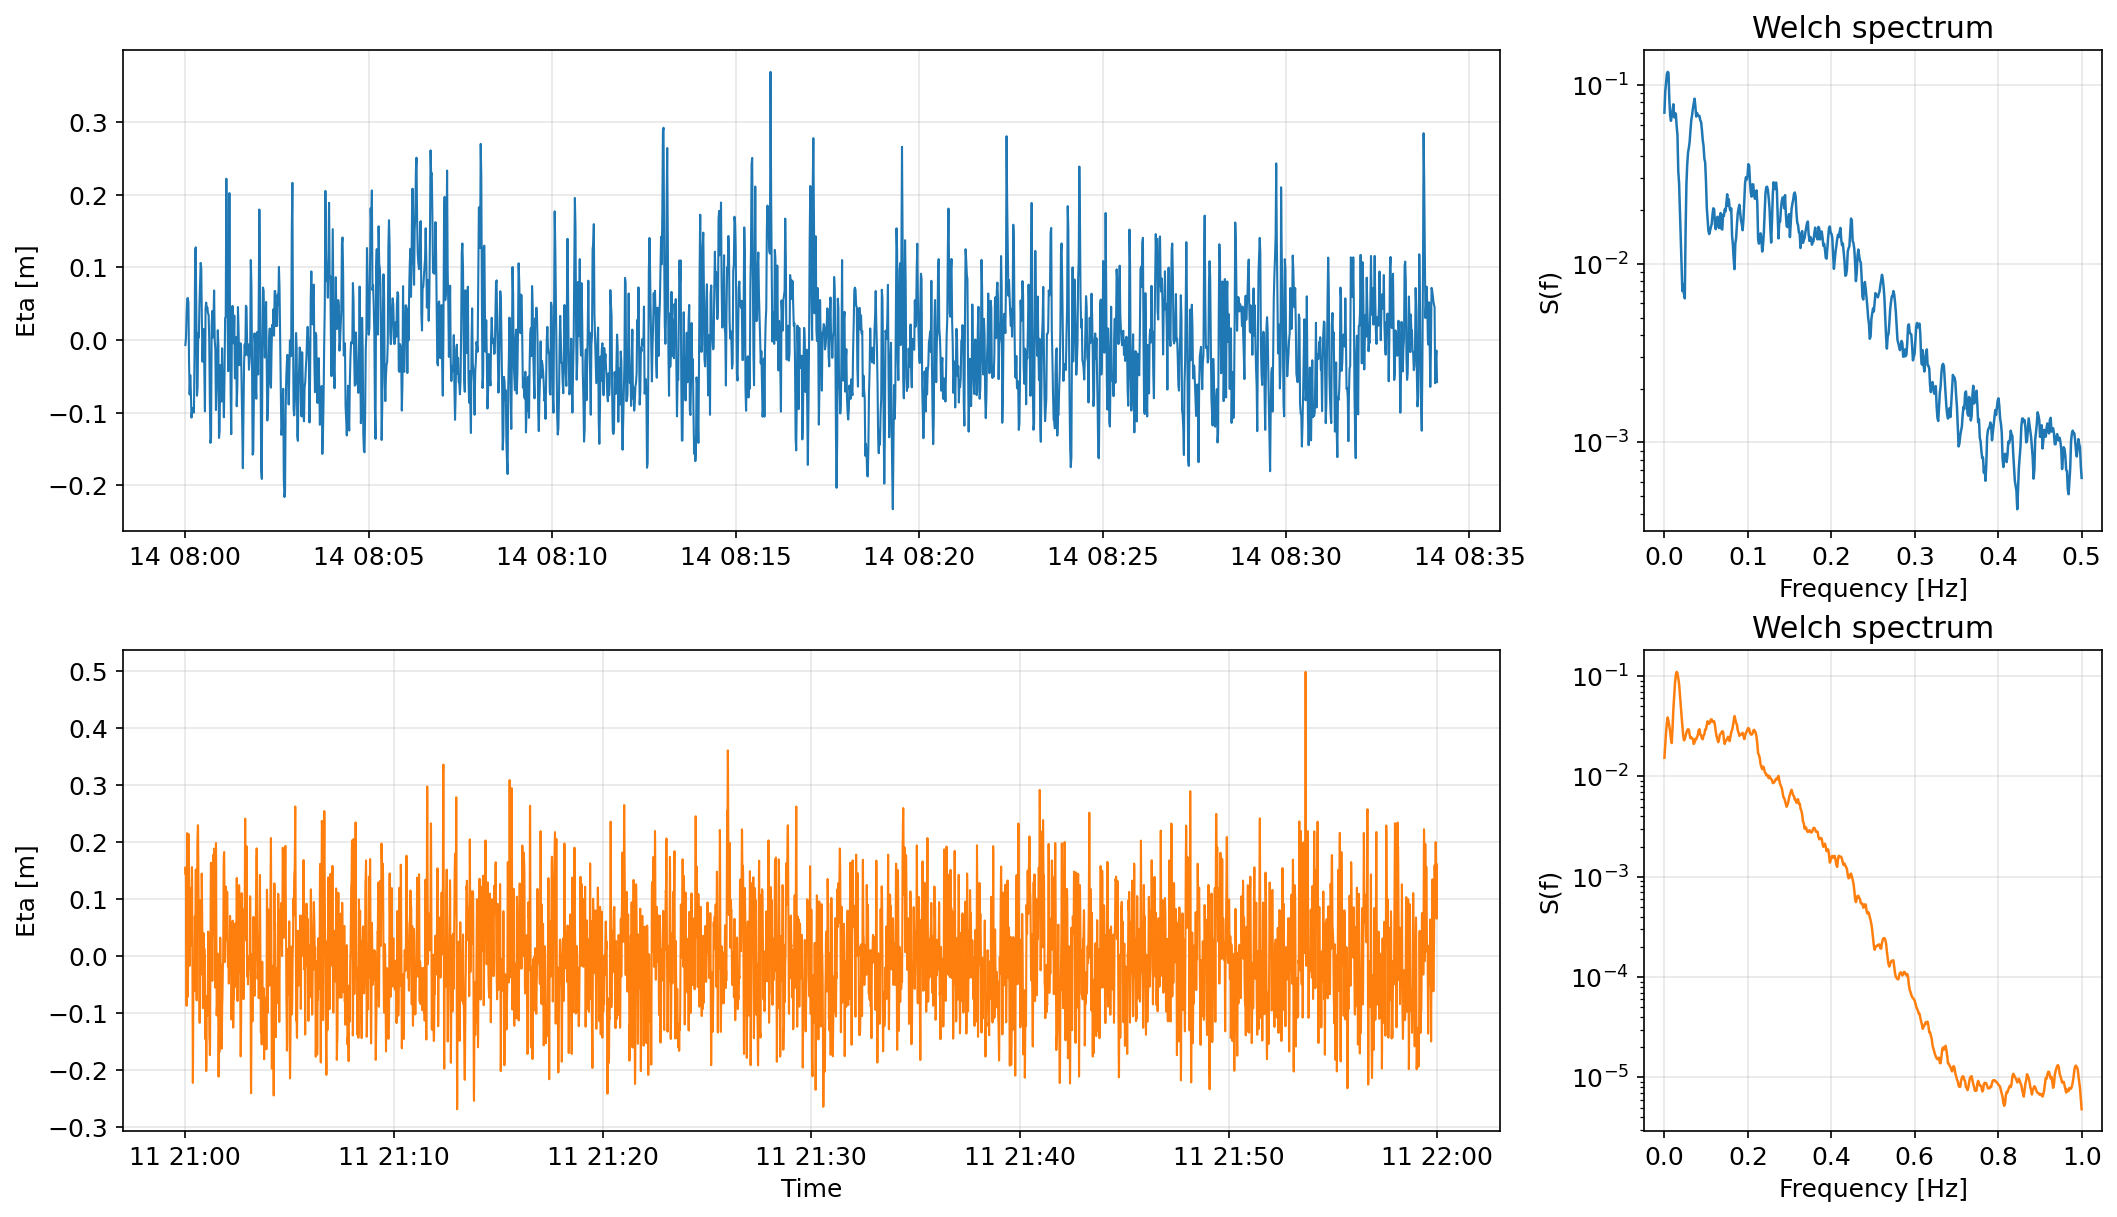

In [12]:
burst_to_plot = 60

AQ_df = dict_clean_measurements["AQ"]
RBR_df = dict_clean_measurements["RBR"]

AQ_burst = AQ_df[AQ_df["burstId"] == burst_to_plot]
RBR_burst = RBR_df[RBR_df["burstId"] == burst_to_plot]

AQ_freq = dict_spectra_welch["AQ"]["freq"]
RBR_freq = dict_spectra_welch["RBR"]["freq"]
AQ_S = dict_spectra_welch["AQ"]["S"][burst_to_plot-1]
RBR_S = dict_spectra_welch["RBR"]["S"][burst_to_plot-1]

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 4)

ax_AQ_timeseries = fig.add_subplot(gs[0, 0:3])
ax_AQ_spectra = fig.add_subplot(gs[0, 3])
ax_RBR_timeseries = fig.add_subplot(gs[1, 0:3])
ax_RBR_spectra = fig.add_subplot(gs[1, 3])

# AQ time series
ax_AQ_timeseries.plot(AQ_burst["eta[m]"], lw=1.0)
ax_AQ_timeseries.set_ylabel("Eta [m]")
ax_AQ_timeseries.grid(True, alpha=0.3)

# AQ spectrum
ax_AQ_spectra.plot(AQ_freq, AQ_S, lw=1.2)
ax_AQ_spectra.set(xlabel="Frequency [Hz]", ylabel="S(f)", title="Welch spectrum", yscale="log")
ax_AQ_spectra.grid(True, alpha=0.3)

# RBR time series
ax_RBR_timeseries.plot(RBR_burst.index, RBR_burst["eta[m]"], lw=1.0, color="tab:orange")
ax_RBR_timeseries.set(xlabel="Time", ylabel="Eta [m]")
ax_RBR_timeseries.grid(True, alpha=0.3)

# RBR spectrum
ax_RBR_spectra.plot(RBR_freq, RBR_S, lw=1.2, color="tab:orange")
ax_RBR_spectra.set(xlabel="Frequency [Hz]", ylabel="S(f)", title="Welch spectrum", yscale="log")
ax_RBR_spectra.grid(True, alpha=0.3)
# plt.show()

## Wavelets transform

In [13]:
for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    if 'AQ' in metadata:   
        pass                     
        # coef_wavelets,freqs_wavelets = SpectralAnalyzer.compute_wavelet_scalograms_for_bursts(window_length=sampling_data[idx]['burst_length_s'],overlap=1,
        #                                                                     mother_wavelet='cmor1.5-1.0',points_scale=50)
        # coef_wavelets = np.stack(coef_wavelets, axis=0)
        # coef_wavelets_full  = coef_wavelets.transpose(1, 0, 2).reshape(len(freqs_wavelets), -1)
    else:
        coef_wavelets_full,freqs_wavelets = SpectralAnalyzer.compute_wavelet_scalogram(mother_wavelet='cmor1.5-1.0',points_scale=50)


<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>
<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


### Plotting the wavelet scalogram

In [14]:
coef_wavelets_full.shape

(50, 1785600)

In [15]:
# This cell can take ages
# fig,ax = plt.subplots(figsize=(14, 6))
# im = ax.imshow(10*np.log10(coef_wavelets_full), aspect='auto',
#                extent=[0, coef_wavelets_full.shape[1], freqs_wavelets[-1], freqs_wavelets[0]])
# # ax.set_yscale('log')
# # ax.set_xlabel('Time [s]')
# # ax.set_ylabel('Frequency [Hz]')